# Redundancy in hidden Transformer layers

In [2]:
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
plt.style.use('ggplot')

cmaps = {
    'cosine': 'Reds', #'RdGy',
    'cka': 'Purples',
    'knn': 'Greens', # 'RdYlGn', #'coolwarm',
    'jacobian': 'RdBu',
}

In [3]:
def plot_heuristic(experiments, ax, res_per_exp=1, relative_layer_idx=False, heuristic='block-influence'):
    assert res_per_exp <= 3
    color_idx = -1
    start_layer_idx = 2
    for exp_name, exp_path in experiments.items():
        results = torch.load(exp_path)
        
        _scores = torch.stack(results[f'all-{heuristic}s']).mean(dim=1)
        n_samples, n_layers = _scores.shape
        color_idx += 1

        if relative_layer_idx:
            xaxis = np.arange(n_layers) / n_layers
            ax.set_xlabel('Normalized depth')
        else:
            xaxis = np.arange(n_layers) + start_layer_idx - 1
            ax.set_xlabel('Layer')

        ax.plot(xaxis, _scores.mean(dim=0), label=exp_name, linestyle='-' if color_idx % res_per_exp == 0 else '--' if color_idx % res_per_exp == 1 else '-.', color=f'C{color_idx // res_per_exp}')
        ax.fill_between(xaxis, _scores.quantile(0.05, dim=0), _scores.quantile(0.95, dim=0), alpha=0.3, color=f'C{color_idx // res_per_exp}')
    

    ax.set(ylabel=f'{heuristic.capitalize()} score [$\mu$ and 90% CI]')
    ax.legend()
    return ax

def plot_block_influence(experiments, ax, res_per_exp=1, relative_layer_idx=False):
    assert res_per_exp <= 3
    color_idx = -1
    start_layer_idx = 2
    for exp_name, exp_path in experiments.items():
        results = torch.load(exp_path)
        if 'all-block-inferences' in results.keys():
            results['all-block-influences'] = results['all-block-inferences']
        
        bi_scores = torch.vstack(results['all-block-influences'])
        n_samples, n_layers = bi_scores.shape
        color_idx += 1

        if relative_layer_idx:
            xaxis = np.arange(n_layers) / n_layers
            ax.set_xlabel('Normalized depth')
        else:
            xaxis = np.arange(n_layers) + start_layer_idx - 1
            ax.set_xlabel('Layer')

        ax.plot(xaxis, bi_scores.mean(dim=0), label=exp_name, linestyle='-' if color_idx % res_per_exp == 0 else '--' if color_idx % res_per_exp == 1 else '-.', color=f'C{color_idx // res_per_exp}')
        ax.fill_between(xaxis, bi_scores.quantile(0.05, dim=0), bi_scores.quantile(0.95, dim=0), alpha=0.3, color=f'C{color_idx // res_per_exp}')
    

    ax.set(ylabel='Block Influence score [$\mu$ and 90% CI]')
    ax.legend()
    return ax

def plot_block_influence_with_multi(experiments, ax, res_per_exp=1, uncertainty=False):
    assert res_per_exp <= 3
    color_idx = -1
    start_layer_idx = 2
    for exp_name, exp_path in experiments.items():
        results = torch.load(exp_path)
        if 'all-block-inferences' in results.keys():
            results['all-block-influences'] = results['all-block-inferences']
        
        for _k in ['all-block-influences', 'all-knn-block-influences']:#, 'all-multi-block-influences']:
            bi_scores = torch.vstack(results[_k])
            n_samples, n_layers = bi_scores.shape
            color_idx += 1
            
            xaxis = np.arange(n_layers) / n_layers
            ax.plot(xaxis, bi_scores.mean(dim=0), label=exp_name + ' - ' + ('kNN-BI' if 'knn' in _k else 'knn-mBI' if 'multi' in _k else 'BI'), linestyle='-' if color_idx % res_per_exp == 0 else '--' if color_idx % res_per_exp == 1 else '-.', color=f'C{color_idx // res_per_exp}')
            if uncertainty:
                ax.fill_between(xaxis, bi_scores.quantile(0.05, dim=0), bi_scores.quantile(0.95, dim=0), alpha=0.3, color=f'C{color_idx // res_per_exp}')

    ax.set(xlabel='Relative layer index', ylabel='Block Influence score [$\mu$ and 90% CI]')
    ax.legend()
    return ax

def merge_results(experiments):
    for i, (exp_name, exp_path) in enumerate(experiments.items()):
        results = torch.load(exp_path)
        if i == 0:
            merged_results = results
        else:
            for k in merged_results['accuracy'].keys():
                for i in range(len(merged_results['accuracy'][k])):
                    try:
                        merged_results['accuracy'][k][i] += results['accuracy'][k][i]
                    except KeyError:
                        pass
                        
            merged_results['all-jacobian-batch-similarities'] += results['all-jacobian-batch-similarities']

    return merged_results

def get_rank(experiments, merge: bool = False, ranks: dict = {}, batch_size=None):
    if merge:
        results = {list(experiments.keys())[0]: merge_results(experiments)}
    else:
        results = {exp_name: torch.load(exp_path) for exp_name, exp_path in experiments.items()}

    for exp_name, res in results.items():
        _batch_size = int(exp_name.split("-")[-1]) if batch_size == 'varying' else batch_size

        num_layers = len(res['all-jacobian-batch-similarities'][0])
        rel_eigvals = torch.zeros((len(res['all-jacobian-batch-similarities']), num_layers))
        for i, _batch_sim_output in enumerate(res['all-jacobian-batch-similarities']):
            for j, (k, _batch_sim_output) in enumerate(_batch_sim_output.items()):
                if batch_size is not None:
                    _batch_sim_output = _batch_sim_output[:_batch_size, :_batch_size]

                eigvals, _ = torch.linalg.eigh(_batch_sim_output)
                rel_eigvals[i, j] = eigvals.max() / sum(eigvals)
        
        ranks[exp_name] = rel_eigvals
    
    return ranks

### Jacobian rank estimation

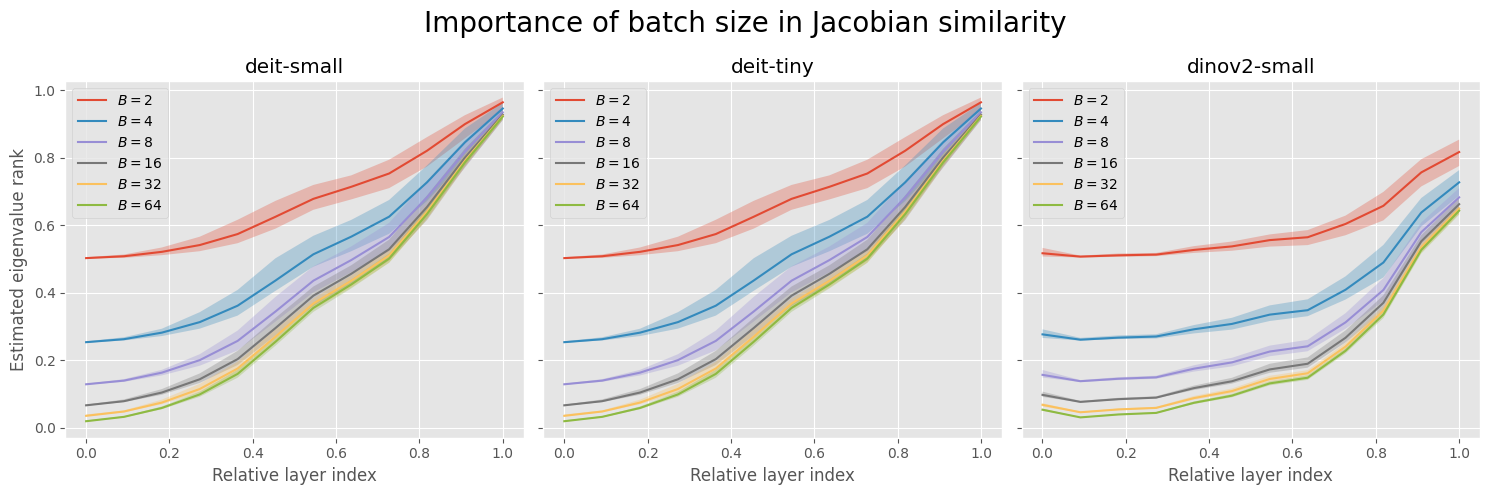

In [3]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments")

_experiments = [
    {
        'deit-small-2' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-4' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-8' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-16': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-32': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-small-64': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    },
    {
        'deit-tiny-2' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-4' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-8' : EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-16': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-32': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
        'deit-tiny-64': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    },
    {
        'dinov2-small-2': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-4': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-8': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-16': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-32': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
        'dinov2-small-64': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
    }
]

fig, axs = plt.subplots(1, len(_experiments), figsize=(int(len(_experiments) * 5), 5), sharey=True)
for i, experiments in enumerate(_experiments):
    ranks = get_rank(experiments, merge=False, ranks={}, batch_size='varying')
    for exp_name, rel_eigvals in ranks.items():
        num_layers = rel_eigvals.shape[1]
        if len(_experiments) == 1:
            axs.plot(np.linspace(0, 1, num_layers), rel_eigvals.mean(dim=0), label=f"$B={exp_name.split('-')[-1]}$")
            axs.fill_between(np.linspace(0, 1, num_layers), rel_eigvals.quantile(0.05, dim=0), rel_eigvals.quantile(0.95, dim=0), alpha=0.3)    
        else:
            axs[i].plot(np.linspace(0, 1, num_layers), rel_eigvals.mean(dim=0), label=f"$B={exp_name.split('-')[-1]}$")
            axs[i].fill_between(np.linspace(0, 1, num_layers), rel_eigvals.quantile(0.05, dim=0), rel_eigvals.quantile(0.95, dim=0), alpha=0.3)    

    if len(_experiments) == 1:
        axs.set_xlabel('Relative layer index', fontsize=16)
        axs.legend()
    else:
        axs[i].set_xlabel('Relative layer index')
        axs[i].set_title("-".join(list(experiments.keys())[0].split("-")[:2]))
        axs[i].legend()

if len(_experiments) == 1:
    axs.set_ylabel('Estimated eigenvalue rank', fontsize=16)
else:
    axs[0].set_ylabel('Estimated eigenvalue rank')
    fig.suptitle('Importance of batch size in Jacobian similarity', fontsize=20)
    
plt.tight_layout()
plt.show()

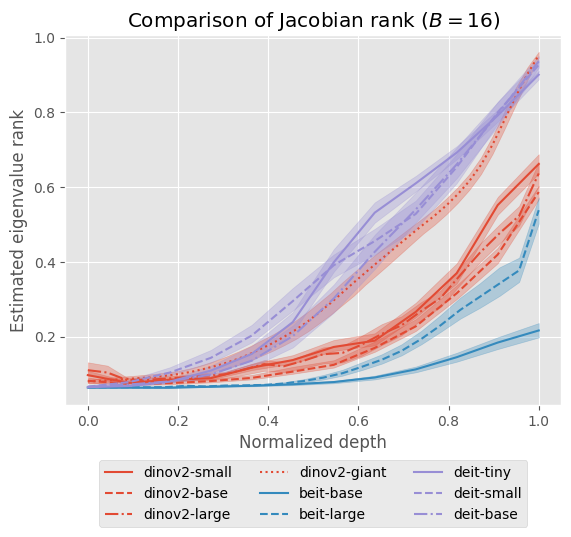

In [4]:
### DiNO
dino_experiments_small = {
    'dinov2-small': EXP_PATH / "vision/dinov2-small-imagenet1k-1-layer/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence'].pth",
}
dino_experiments_base = {
    'dinov2-base': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter0.pth",
    'dinov2-base-10': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter10.pth",
    'dinov2-base-20': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter20.pth",
    'dinov2-base-30': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter30.pth",
    'dinov2-base-40': EXP_PATH / "vision/dinov2-base-imagenet1k-1-layer/iter40.pth",
}
dino_experiments_large = {
    'dinov2-large': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter0.pth",
    'dinov2-large-5': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter5.pth",
    'dinov2-large-10': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter10.pth",
    'dinov2-large-15': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter15.pth",
    'dinov2-large-20': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter20.pth",
    'dinov2-large-25': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter25.pth",
    'dinov2-large-30': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter30.pth",
    'dinov2-large-35': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter35.pth",
    'dinov2-large-40': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter40.pth",
    'dinov2-large-45': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/iter45.pth",
}
dino_experiments_giant = {
    'dinov2-giant': EXP_PATH / "vision/dinov2-giant-imagenet1k-1-layer/iter0.pth",
}
dino_experiments_giant.update({
    f'dinov2-giant-{i}': EXP_PATH / f"vision/dinov2-giant-imagenet1k-1-layer/iter{i}.pth" for i in range(1, 49)
})

ranks = get_rank(dino_experiments_small, ranks={}, batch_size=16)
ranks = get_rank(dino_experiments_base, merge=True, ranks=ranks, batch_size=16)
ranks = get_rank(dino_experiments_large, merge=True, ranks=ranks, batch_size=16)
ranks = get_rank(dino_experiments_giant, merge=True, ranks=ranks, batch_size=16)

# BEIT
beit_experiments_base = {
    'beit-base': EXP_PATH / "vision/beit-base/iter0.pth",
    'beit-base-15': EXP_PATH / "vision/beit-base/iter15.pth",
    'beit-base-35': EXP_PATH / "vision/beit-base/iter35.pth",
}
beit_experiments_large = {
    # 'beit-large': EXP_PATH / "vision/beit-large/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'beit-large': EXP_PATH / "vision/beit-large/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=1_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'beit-large-10': EXP_PATH / "vision/beit-large/iter10.pth",
    'beit-large-20': EXP_PATH / "vision/beit-large/iter20.pth",
    'beit-large-30': EXP_PATH / "vision/beit-large/iter30.pth",
    'beit-large-40': EXP_PATH / "vision/beit-large/iter40.pth",
}
ranks = get_rank(beit_experiments_base, ranks=ranks, merge=True, batch_size=16)
ranks = get_rank(beit_experiments_large, ranks=ranks, merge=True, batch_size=16)

### DEIT
deit_experiments = {
    'deit-tiny': EXP_PATH / "vision/deit-tiny/within=False_['pruning-performance', 'jacobian-similarity']_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'deit-small': EXP_PATH / "vision/deit-small/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
}
deit_experiments_base = {
    'deit-base': EXP_PATH / "vision/deit-base/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'deit-base-20': EXP_PATH / "vision/deit-base/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=20_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
    'deit-base-40': EXP_PATH / "vision/deit-base/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=40_pruned-by=['forward', 'backward', 'block-influence', 'jacobian-rank']_results.pth",
}
ranks = get_rank(deit_experiments, ranks=ranks, batch_size=16)
ranks = get_rank(deit_experiments_base, ranks=ranks, merge=True, batch_size=16)

previous_exp = ''
color_idx = -1
linestyle_idx = 0
linestyles = ['-', '--', '-.', ':']

for exp_name, rel_eigvals in ranks.items():
    if exp_name.split("-")[0] in previous_exp:
        linestyle_idx += 1
    else:
        color_idx += 1
        linestyle_idx = 0

    num_layers = rel_eigvals.shape[1]
    plt.plot(np.linspace(0, 1, num_layers), rel_eigvals.mean(dim=0), label=exp_name, color=f'C{color_idx}', linestyle=linestyles[linestyle_idx])
    plt.fill_between(np.linspace(0, 1, num_layers), rel_eigvals.quantile(0.025, dim=0), rel_eigvals.quantile(0.975, dim=0), alpha=0.3, color=f'C{color_idx}')    
    
    previous_exp = exp_name

plt.xlabel('Normalized depth')
plt.ylabel('Estimated eigenvalue rank')
plt.legend(ncols=3, loc='lower center', bbox_to_anchor=(0.5, -0.35))
plt.title('Comparison of Jacobian rank ($B=16$)')
plt.show()

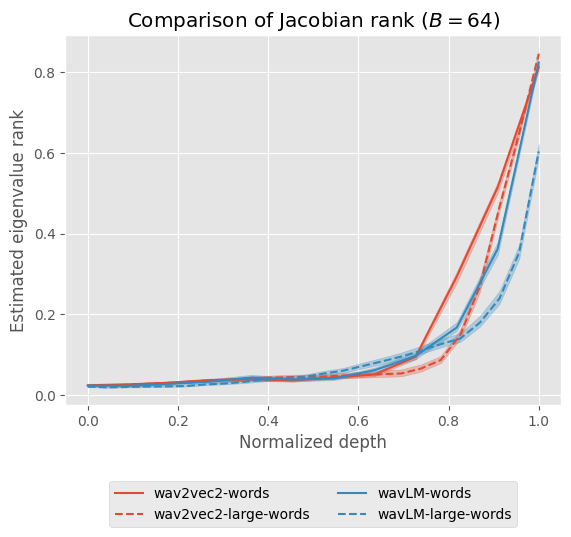

In [5]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments")

batch_size = 64

### DiNO
wav2vec2_experiments = {
    'wav2vec2-words': EXP_PATH / "audio/wav2vec2-words/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence']_results.pth",
    'wav2vec2-large-words': EXP_PATH / "audio/wav2vec2-large-words/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence']_results.pth",
}
wavlm_experiments = {
    'wavLM-words': EXP_PATH / "audio/wavLM-words/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence']_results.pth",
    'wavLM-large-words': EXP_PATH / "audio/wavLM-large-words/within=False_['pruning-performance', 'jacobian-similarity']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence']_results.pth",
}

ranks = get_rank(wav2vec2_experiments, ranks={}, batch_size=batch_size)
ranks = get_rank(wavlm_experiments, ranks=ranks, batch_size=batch_size)

previous_exp = ''
color_idx = -1
linestyle_idx = 0
linestyles = ['-', '--', '-.', ':']

for exp_name, rel_eigvals in ranks.items():
    if exp_name.split("-")[0] in previous_exp:
        linestyle_idx += 1
    else:
        color_idx += 1
        linestyle_idx = 0

    num_layers = rel_eigvals.shape[1]
    plt.plot(np.linspace(0, 1, num_layers), rel_eigvals.mean(dim=0), label=exp_name, color=f'C{color_idx}', linestyle=linestyles[linestyle_idx])
    plt.fill_between(np.linspace(0, 1, num_layers), rel_eigvals.quantile(0.025, dim=0), rel_eigvals.quantile(0.975, dim=0), alpha=0.3, color=f'C{color_idx}')    
    
    previous_exp = exp_name

plt.xlabel('Normalized depth')
plt.ylabel('Estimated eigenvalue rank')
plt.legend(ncols=2, loc='lower center', bbox_to_anchor=(0.5, -0.35))
plt.title(f'Comparison of Jacobian rank ($B={batch_size}$)')
plt.show()

### Similarity and pruning (audio)

In [4]:
def plot_similarity_matrix(ax, sims, _type):
    # norm = TwoSlopeNorm(vmin=min(sims.min(), -1e-7), vcenter=0., vmax=max(sims.max(), 1e-7))
    # cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmaps[_type])
    # ax.imshow(sims, cmap=cmaps[_type], norm=norm)
    img = ax.imshow(sims, cmap=cmaps[_type])
    fig.colorbar(img, ax=ax, fraction=0.04)
    ax.grid(False)

def plot_knn_similarities(ks, mutual_knn_within, mutual_knn_between, exp_name, offset):
    for i, _knn in enumerate([mutual_knn_within, mutual_knn_between]):
        for j, _k in enumerate(ks):
            plot_similarity_matrix(axs[i, j + offset], _knn[_k].mean(dim=0), 'knn')
            axs[i, j + offset].set_xlabel('Layer index') if i == 1 else axs[i, j + offset].set_title(f"$k$NN ($k={_k}$)")

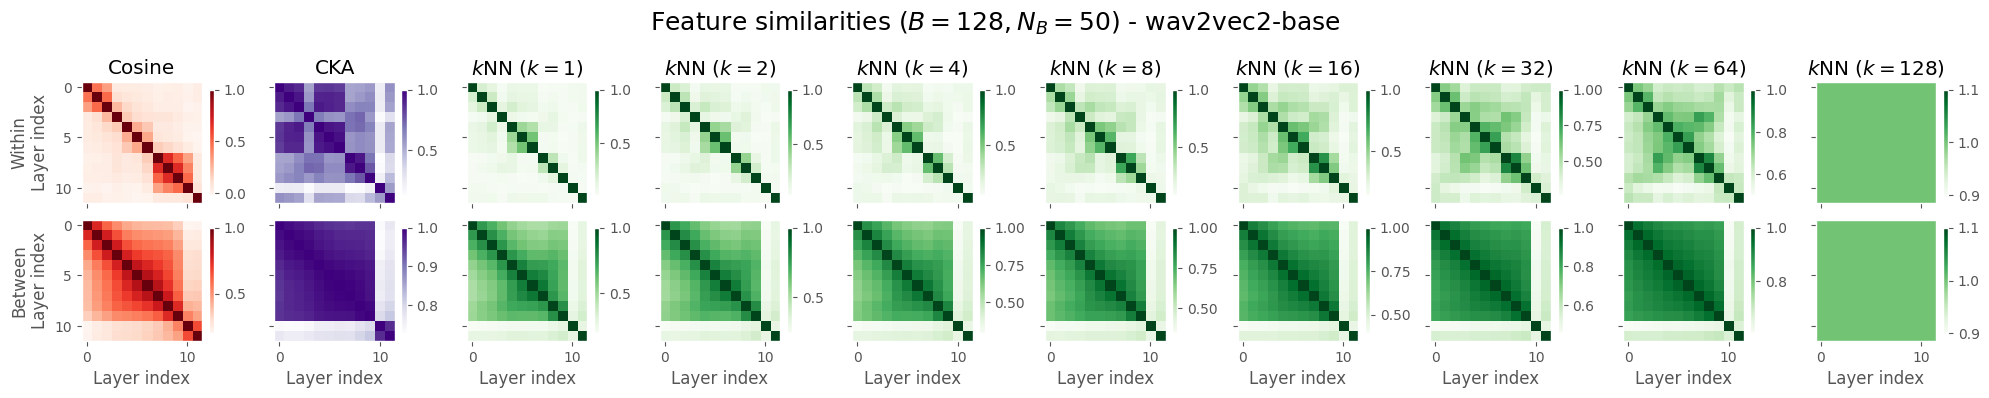

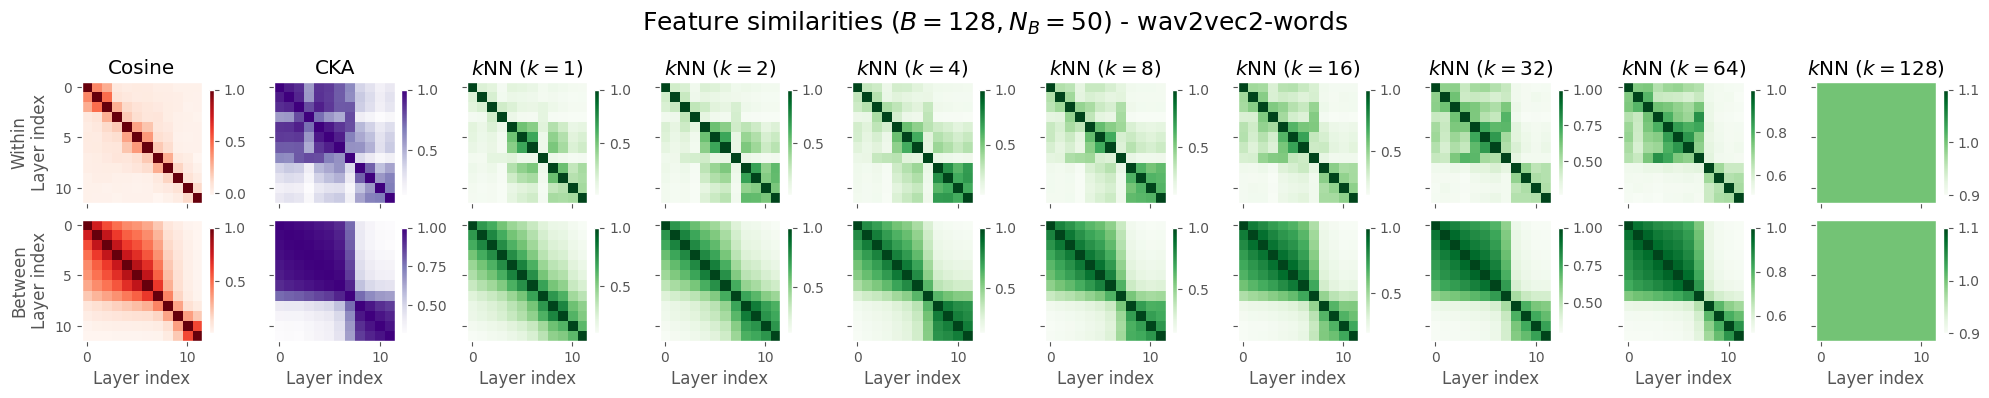

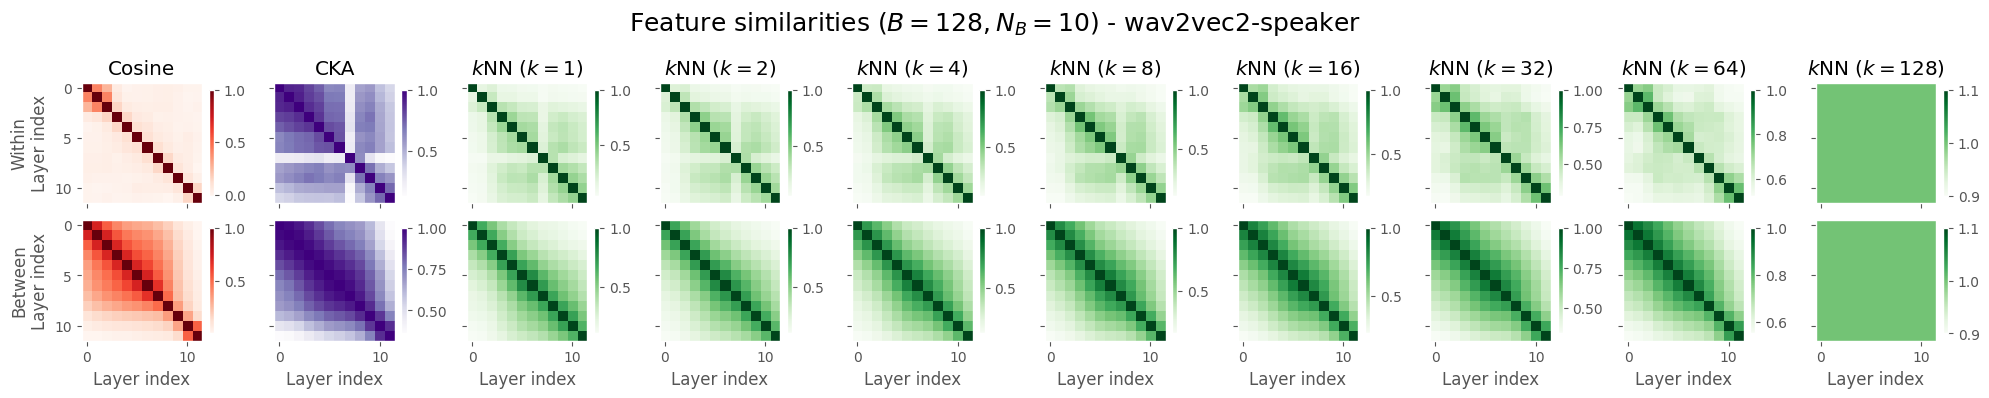

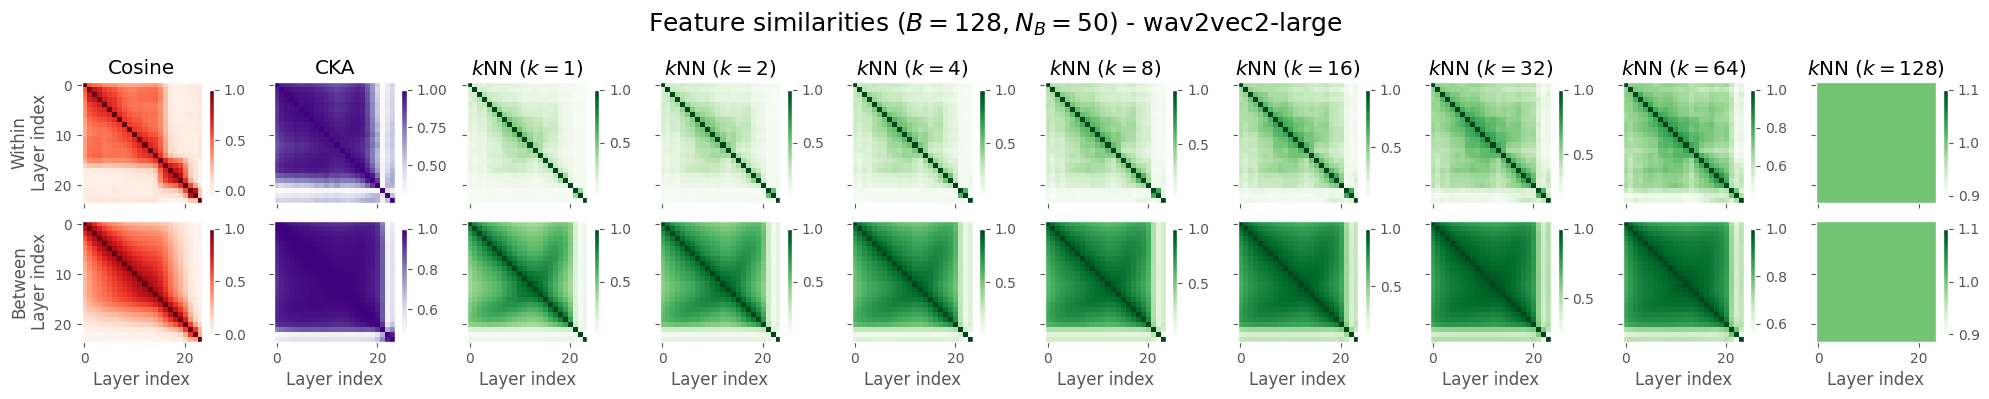

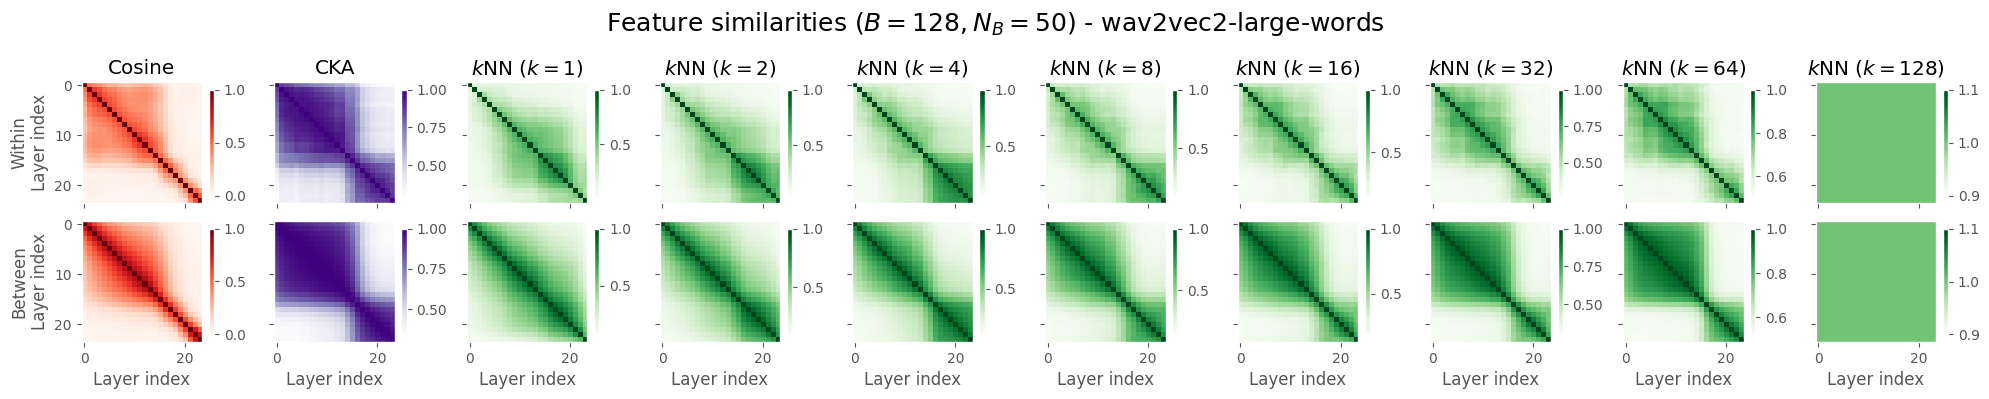

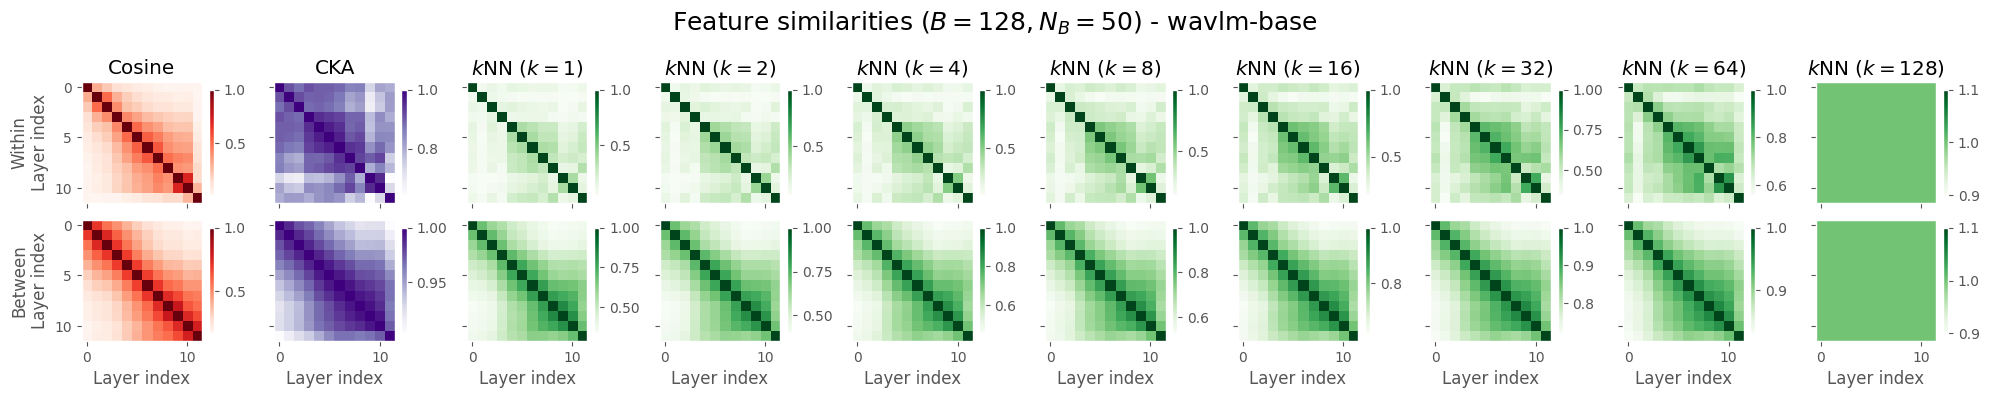

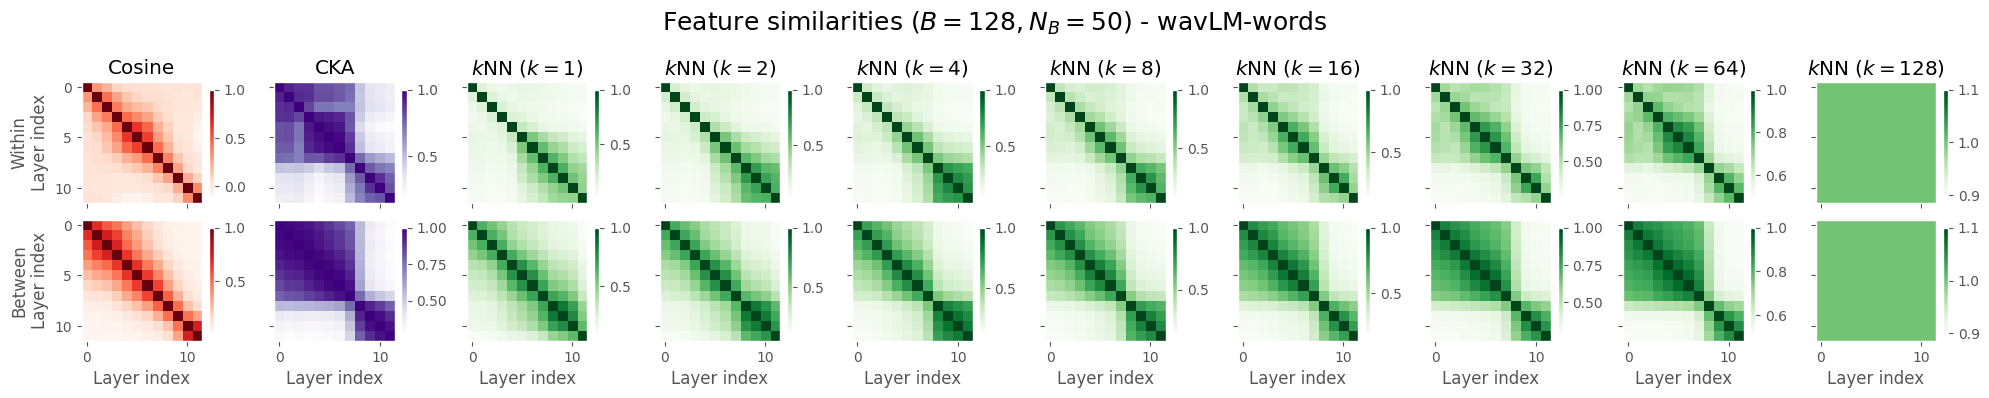

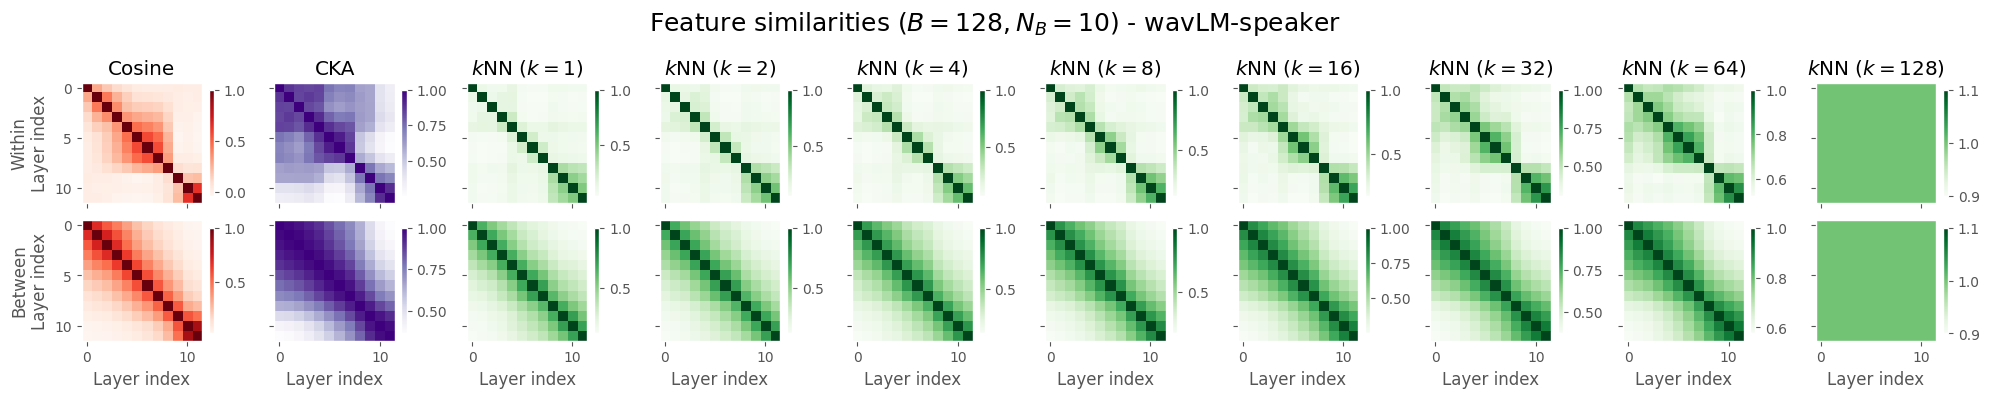

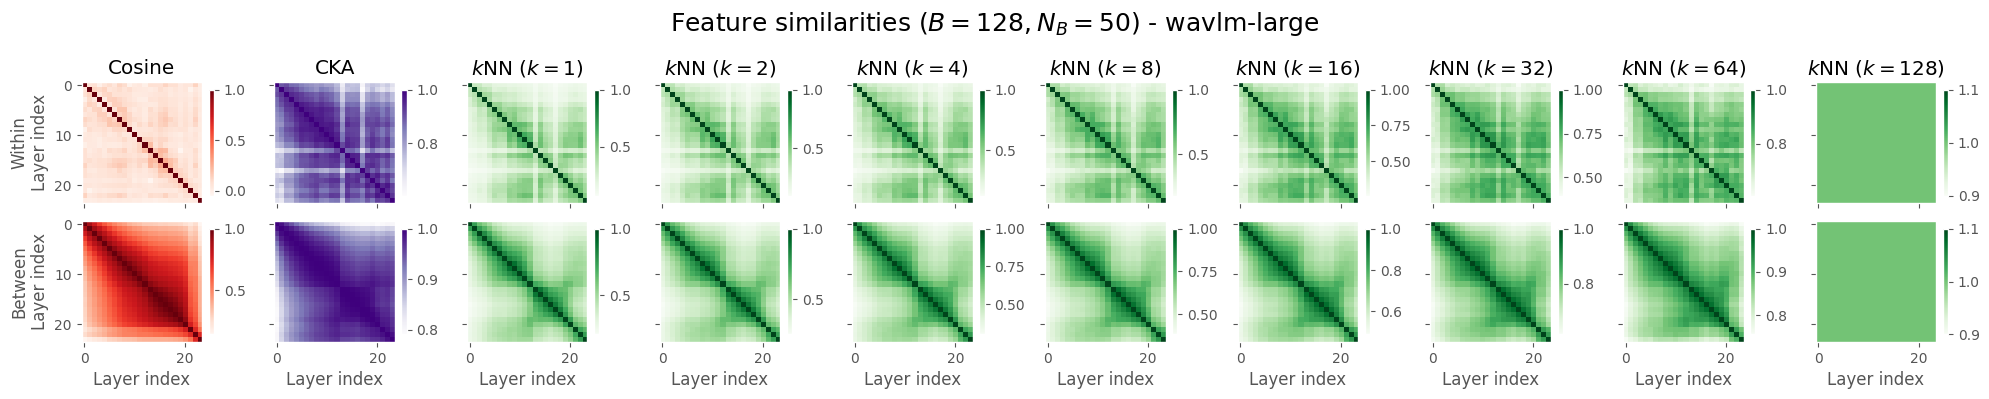

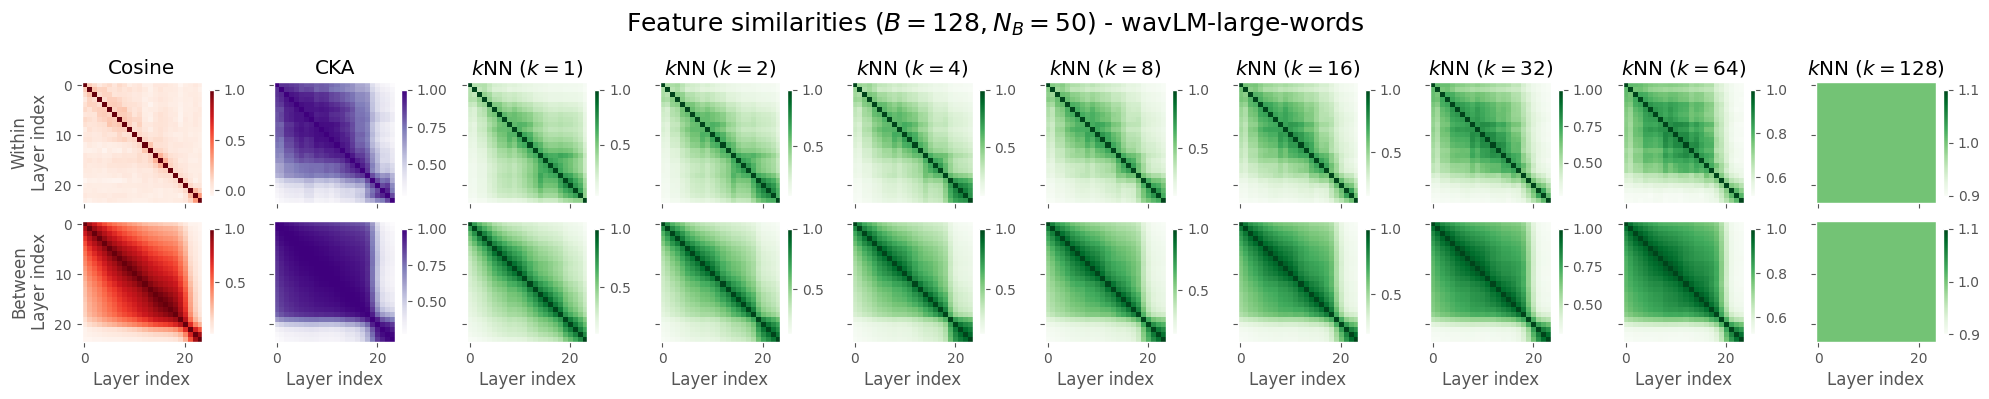

In [13]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/similarities")

experiments = {
    'wav2vec2-base': EXP_PATH / "audio/wav2vec2-base/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'wav2vec2-words': EXP_PATH / "audio/wav2vec2-words/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'wav2vec2-speaker': EXP_PATH / "audio/wav2vec2-speaker/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'wav2vec2-large': EXP_PATH / "audio/wav2vec2-large/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'wav2vec2-large-words': EXP_PATH / "audio/wav2vec2-large-words/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    # 'wav2vec2-large-speaker': EXP_PATH / "audio/wav2vec2-large-speaker/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'wavlm-base': EXP_PATH / "audio/wavlm-base/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'wavLM-words': EXP_PATH / "audio/wavLM-words/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'wavLM-speaker': EXP_PATH / "audio/wavLM-speaker/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'wavlm-large': EXP_PATH / "audio/wavlm-large/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'wavLM-large-words': EXP_PATH / "audio/wavLM-large-words/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    # 'wavLM-large-speaker': EXP_PATH / "audio/wavLM-large-speaker/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
}

i = -1
for exp_name, exp_path in experiments.items():
    i += 1
    # Load results
    res = torch.load(exp_path)
    
    # Extract cosine similarities
    cos_within = torch.stack([elem['within'] for elem in res['all-cosine-similarities']])
    cos_between = torch.stack([elem['between'] for elem in res['all-cosine-similarities']])
    N_b = cos_within.shape[0]
    
    # Extract CKA similarities
    cka = torch.stack(res['all-cka-similarities'])
    cka_within = cka[:, ::2, ::2]
    cka_between = cka[:, 1::2, 1::2]

    # Extract mutual kNN similarities
    ks = res['all-mutual_knn-similarities']['within'][0].keys()
    mutual_knn_within = {k: torch.stack([res['all-mutual_knn-similarities']['within'][i][k] for i in range(N_b)]) for k in ks}
    mutual_knn_between = {k: torch.stack([res['all-mutual_knn-similarities']['between'][i][k] for i in range(N_b)]) for k in ks}

    fig, axs = plt.subplots(2, len(ks) + 2, figsize=(2*(len(ks) + 2), 4), sharex=True, sharey=True)

    # Plot cosine and CKA similarities
    plot_similarity_matrix(axs[0, 0], cos_within.mean(dim=0), 'cosine')
    plot_similarity_matrix(axs[1, 0], cos_between.mean(dim=0), 'cosine')
    axs[0, 0].set_title("Cosine")
    plot_similarity_matrix(axs[0, 1], cka_within.mean(dim=0), 'cka')
    plot_similarity_matrix(axs[1, 1], cka_between.mean(dim=0), 'cka')
    axs[0, 1].set_title('CKA')

    # Plot kNN similarities
    plot_knn_similarities(ks, mutual_knn_within, mutual_knn_between, exp_name, offset=2)

    axs[0, 0].set_ylabel("Within\nLayer index")
    axs[1, 0].set_ylabel("Between\nLayer index")
    axs[1, 0].set_xlabel('Layer index'); axs[1, 1].set_xlabel('Layer index')

    fig.suptitle(f"Feature similarities ($B={max(ks)}, N_B = {N_b}$) - {exp_name}", fontsize=18)
    plt.tight_layout()
    plt.show()

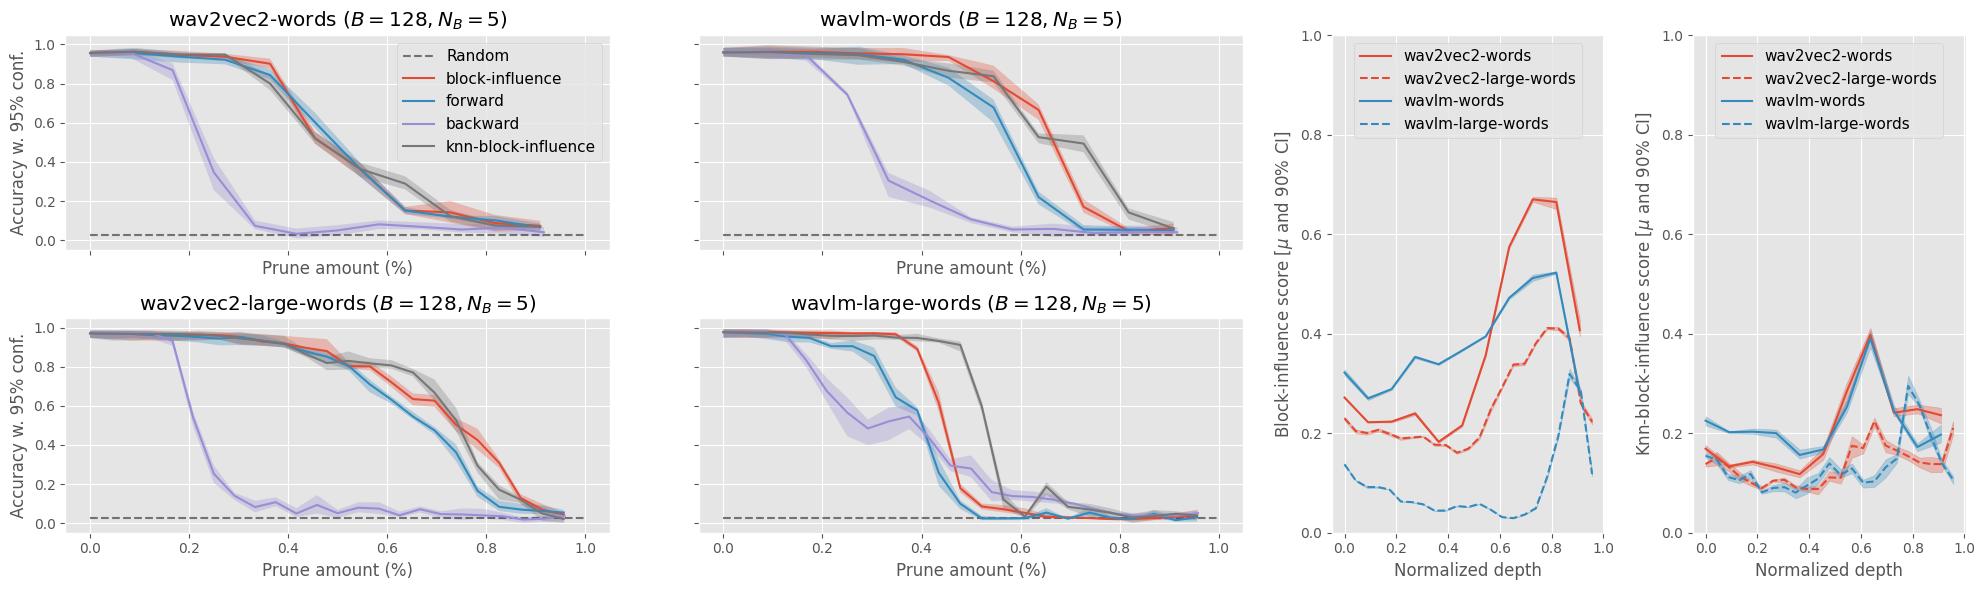

In [24]:
num_classes = 35
_conf = 95
_alpha = round((1 - _conf / 100), 2)

EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/pruning/standard")

fig, axs = plt.subplots(2, 2+2, figsize=(5*(2+2), 6), sharey=True, gridspec_kw={'width_ratios': [1, 1, 0.5, 0.5]}, sharex='col')

for _row, size in enumerate(['', '-large']):
    if size == '':
        all_results = {
            f'wav2vec2{size}-words': torch.load(EXP_PATH / f"audio/wav2vec2{size}-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'knn-block-influence']_results.pth"),
            f'wavlm{size}-words': torch.load(EXP_PATH / f"audio/wavlm{size}-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'knn-block-influence']_results.pth"),
        }
    else:
        all_results = {
            f'wav2vec2{size}-words': torch.load(EXP_PATH / f"audio/wav2vec2{size}-words/within=False_['pruning-performance']_start-iter=0_pruned-by=[]_results.pth"),
            f'wavlm{size}-words': torch.load(EXP_PATH / f"audio/wavlm{size}-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'knn-block-influence']_results.pth"),
        }

    for i, (exp_name, results) in enumerate(all_results.items()):
        n_batches = results['accuracy']['forward'][0].__len__()
        batch_size = results['all-block-influences'][0].shape[0]
        num_layers = results['all-block-influences'][0].shape[1] + 1

        axs[_row, i].hlines(1/num_classes, xmin=0, xmax=1, color='black', linestyle='--', alpha=0.5, label='Random')

        for pruning_strategy in ['block-influence', 'forward', 'backward', 'knn-block-influence']:
            mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
            lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
            upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
    
            xaxis = np.arange(len(mean_accs.keys())) / len(mean_accs.keys())
            axs[_row, i].fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3)
            axs[_row, i].plot(xaxis, list(mean_accs.values()), label=pruning_strategy)

        axs[_row, i].set(xlabel='Prune amount (%)', title=f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)')
        # axs[_row, i].set_xticks(range(num_layers)[::num_layers // 10], range(num_layers)[::num_layers // 10])
    axs[_row, 0].set(ylabel=f'Accuracy w. {_conf}% conf.')

axs[0, 0].legend(loc='upper right', fontsize=11)

# Plot block influence scores
experiments = {
    f'wav2vec2-words': EXP_PATH / f"audio/wav2vec2-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'knn-block-influence']_results.pth",
    f'wav2vec2-large-words': EXP_PATH / f"audio/wav2vec2-large-words/within=False_['pruning-performance']_start-iter=0_pruned-by=[]_results.pth",
    f'wavlm-words': EXP_PATH / f"audio/wavlm-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'knn-block-influence']_results.pth",
    f'wavlm-large-words': EXP_PATH / f"audio/wavlm-large-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['forward', 'backward', 'block-influence', 'knn-block-influence']_results.pth",
}

for _ax_idx in [2, 3]:
    gs = axs[0, 2].get_gridspec()
    # remove the underlying Axes
    for ax in axs[0:, _ax_idx]:
        ax.remove()
    axbig = fig.add_subplot(gs[0:, _ax_idx])
    plot_heuristic(experiments, axbig, res_per_exp=2, relative_layer_idx=True, heuristic='block-influence' if _ax_idx == 2 else 'knn-block-influence')
    axbig.set_ylim(0., 1.)
    axbig.legend(loc='upper center', fontsize=11)

plt.tight_layout()
plt.show()

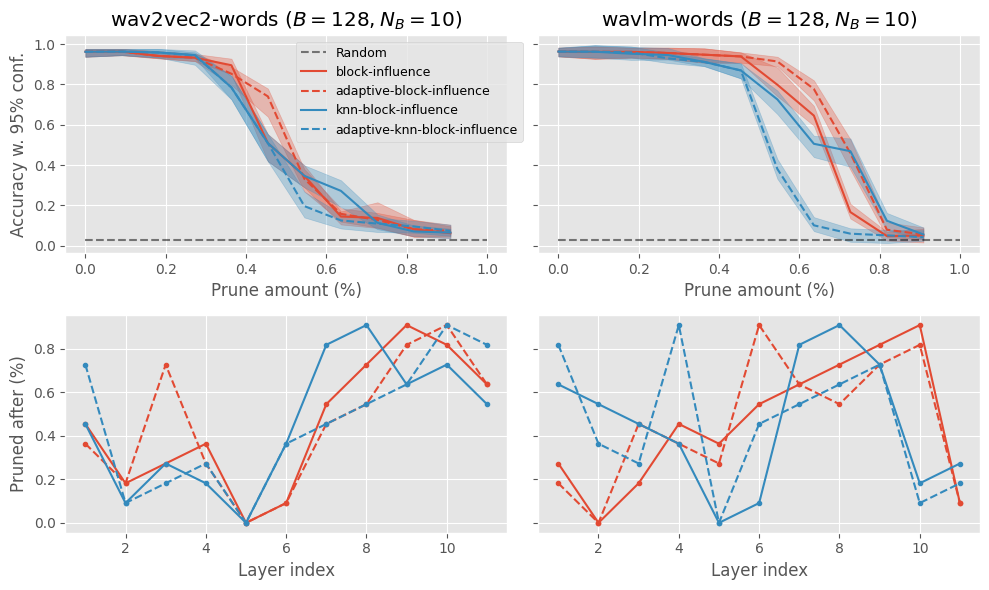

In [9]:
num_classes = 35
_conf = 95
_alpha = round((1 - _conf / 100), 2)

EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/pruning/adaptive")

fig, axs = plt.subplots(2, 2, figsize=(5*(2), 6), gridspec_kw={'width_ratios': [1, 1]}, sharex='row', sharey='row')

all_results = {
    f'wav2vec2-words': torch.load(EXP_PATH / f"audio/wav2vec2-words/bs128_10iter_results.pth"),
    f'wavlm-words': torch.load(EXP_PATH / f"audio/wavlm-words/bs128_10iter_results.pth"),
}

for i, (exp_name, results) in enumerate(all_results.items()):
    _row = 0
    n_batches = results['accuracy']['block-influence'][0].__len__()
    batch_size = results['all-block-influences'][0].shape[0]
    num_layers = results['all-block-influences'][0].shape[1] + 1

    axs[_row, i].hlines(1/num_classes, xmin=0, xmax=1, color='black', linestyle='--', alpha=0.5, label='Random')

    for p, pruning_strategy in enumerate(['block-influence', 'adaptive-block-influence', 'knn-block-influence', 'adaptive-knn-block-influence']):
        mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
        lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
        upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}

        xaxis = np.arange(len(mean_accs.keys())) / len(mean_accs.keys())
        axs[_row, i].fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3, color=f'C{p // 2}')
        axs[_row, i].plot(xaxis, list(mean_accs.values()), label=pruning_strategy, color=f'C{p // 2}', linestyle=['-', '--'][p % 2])

    axs[_row, i].set(xlabel='Prune amount (%)', title=f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)')


    bi_order = torch.argsort(torch.mean(torch.vstack(results['all-block-influences']), dim=0), descending=False) + 1 
    abi_order = torch.tensor(results['all-adaptive-block-influences'])# .mode(dim=0).values
    knn_order = torch.argsort(torch.mean(torch.vstack(results['all-knn-block-influences']), dim=0), descending=False) + 1
    aknn_order = torch.tensor(results['all-adaptive-knn-block-influences'])# .mode(dim=0).values

    _row = 1
    names = ['BI', 'aBI', 'kNN', 'aKNN']
    for p, order in enumerate([bi_order, abi_order, knn_order, aknn_order]):
        if 'a' in names[p]:
            if order.mode(dim=0).values.unique().__len__() != order.mode(dim=0).values.__len__():
                order = order[0]
            else:
                order = order.mode(dim=0).values

        xaxis = np.arange(len(order)) 
        axs[_row, i].plot(xaxis + 1, order.argsort() / len(order), marker='.', label=names[i], linestyle=['-', '--'][p % 2], color=f'C{p // 2}')
        axs[_row, i].set_xlabel('Layer index')
        

axs[0, 0].set(ylabel=f'Accuracy w. {_conf}% conf.')
axs[1, 0].set_ylabel('Pruned after (%)')
axs[0, 0].legend(loc='upper right', fontsize=9, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

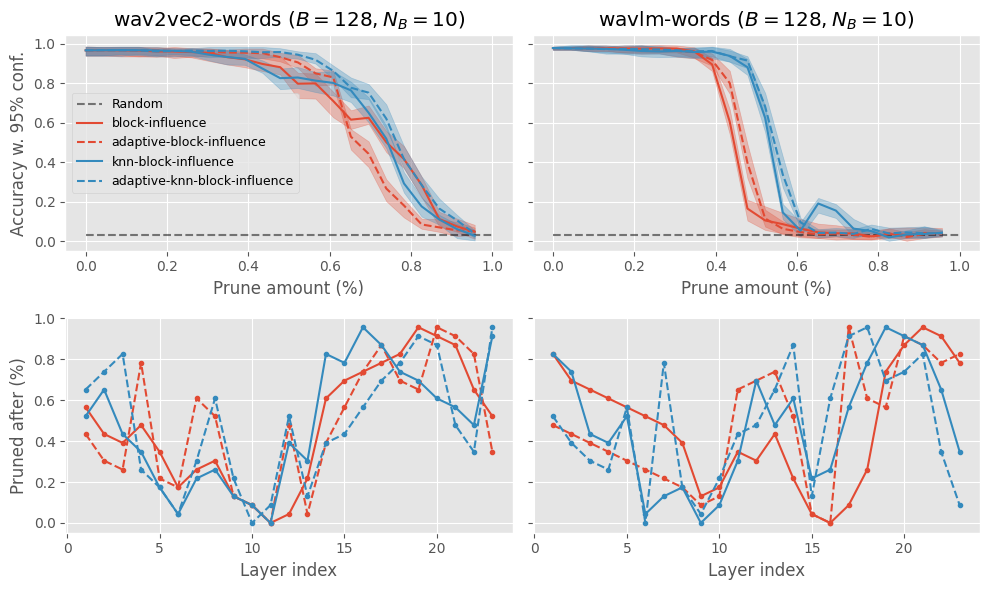

In [17]:
num_classes = 35
_conf = 95
_alpha = round((1 - _conf / 100), 2)

EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/pruning/adaptive")

fig, axs = plt.subplots(2, 2, figsize=(5*(2), 6), gridspec_kw={'width_ratios': [1, 1]}, sharex='row', sharey='row')

all_results = {
    f'wav2vec2-words': torch.load(EXP_PATH / f"audio/wav2vec2-large-words/bs128_10iter_results.pth"),
    f'wavlm-words': torch.load(EXP_PATH / f"audio/wavlm-large-words/bs128_10iter_results.pth"),
}

for i, (exp_name, results) in enumerate(all_results.items()):
    _row = 0
    n_batches = results['accuracy']['block-influence'][0].__len__()
    batch_size = results['all-block-influences'][0].shape[0]
    num_layers = results['all-block-influences'][0].shape[1] + 1

    axs[_row, i].hlines(1/num_classes, xmin=0, xmax=1, color='black', linestyle='--', alpha=0.5, label='Random')

    for p, pruning_strategy in enumerate(['block-influence', 'adaptive-block-influence', 'knn-block-influence', 'adaptive-knn-block-influence']):
        mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
        lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
        upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}

        xaxis = np.arange(len(mean_accs.keys())) / len(mean_accs.keys())
        axs[_row, i].fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3, color=f'C{p // 2}')
        axs[_row, i].plot(xaxis, list(mean_accs.values()), label=pruning_strategy, color=f'C{p // 2}', linestyle=['-', '--'][p % 2])

    axs[_row, i].set(xlabel='Prune amount (%)', title=f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)')


    bi_order = torch.argsort(torch.mean(torch.vstack(results['all-block-influences']), dim=0), descending=False) + 1 
    abi_order = torch.tensor(results['all-adaptive-block-influences'])# .mode(dim=0).values
    knn_order = torch.argsort(torch.mean(torch.vstack(results['all-knn-block-influences']), dim=0), descending=False) + 1
    aknn_order = torch.tensor(results['all-adaptive-knn-block-influences'])# .mode(dim=0).values

    _row = 1
    names = ['BI', 'aBI', 'kNN', 'aKNN']
    for p, order in enumerate([bi_order, abi_order, knn_order, aknn_order]):
        if 'a' in names[p]:
            if order.mode(dim=0).values.unique().__len__() != order.mode(dim=0).values.__len__():
                order = order[0]
            else:
                order = order.mode(dim=0).values

        xaxis = np.arange(len(order)) 
        axs[_row, i].plot(xaxis + 1, order.argsort() / len(order), marker='.', label=names[i], linestyle=['-', '--'][p % 2], color=f'C{p // 2}')
        axs[_row, i].set_xlabel('Layer index')
        

axs[0, 0].set(ylabel=f'Accuracy w. {_conf}% conf.')
axs[1, 0].set_ylabel('Pruned after (%)')
axs[0, 0].legend(loc='center left', fontsize=9)#  bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

```
wav2vec2-large (first - outside-in): 15 16 1 2 3 4 5 6 7 8 9 10 11 12 13 14 23 22 21 20 19 18 17
wav2vec2-large (first - inside-out): 15 16 14 13 12 11 10 9 8 7 6 5 4 3 2 1 17 18 19 20 21 22 23
wav2vec2-large (last - outside-in): 1 2 3 4 5 6 7 8 9 10 11 12 13 14 23 22 21 20 19 18 17 15 16
wav2vec2-large (last - inside-out): 14 13 12 11 10 9 8 7 6 5 4 3 2 1 17 18 19 20 21 22 23 15 16

wavLM-large (first - outside-in): 18 19 17 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 23 22 21 20
wavLM-large (first - inside-out): 18 19 17 16 15 14 13 12 11 10 9 8 7 6 5 4 3 2 1 20 21 22 23
wavLM-large (last - outside-in): 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 23 22 21 20 18 19 17
wavLM-large (last - inside-out): 16 15 14 13 12 11 10 9 8 7 6 5 4 3 2 1 20 21 22 23 18 19 17
```

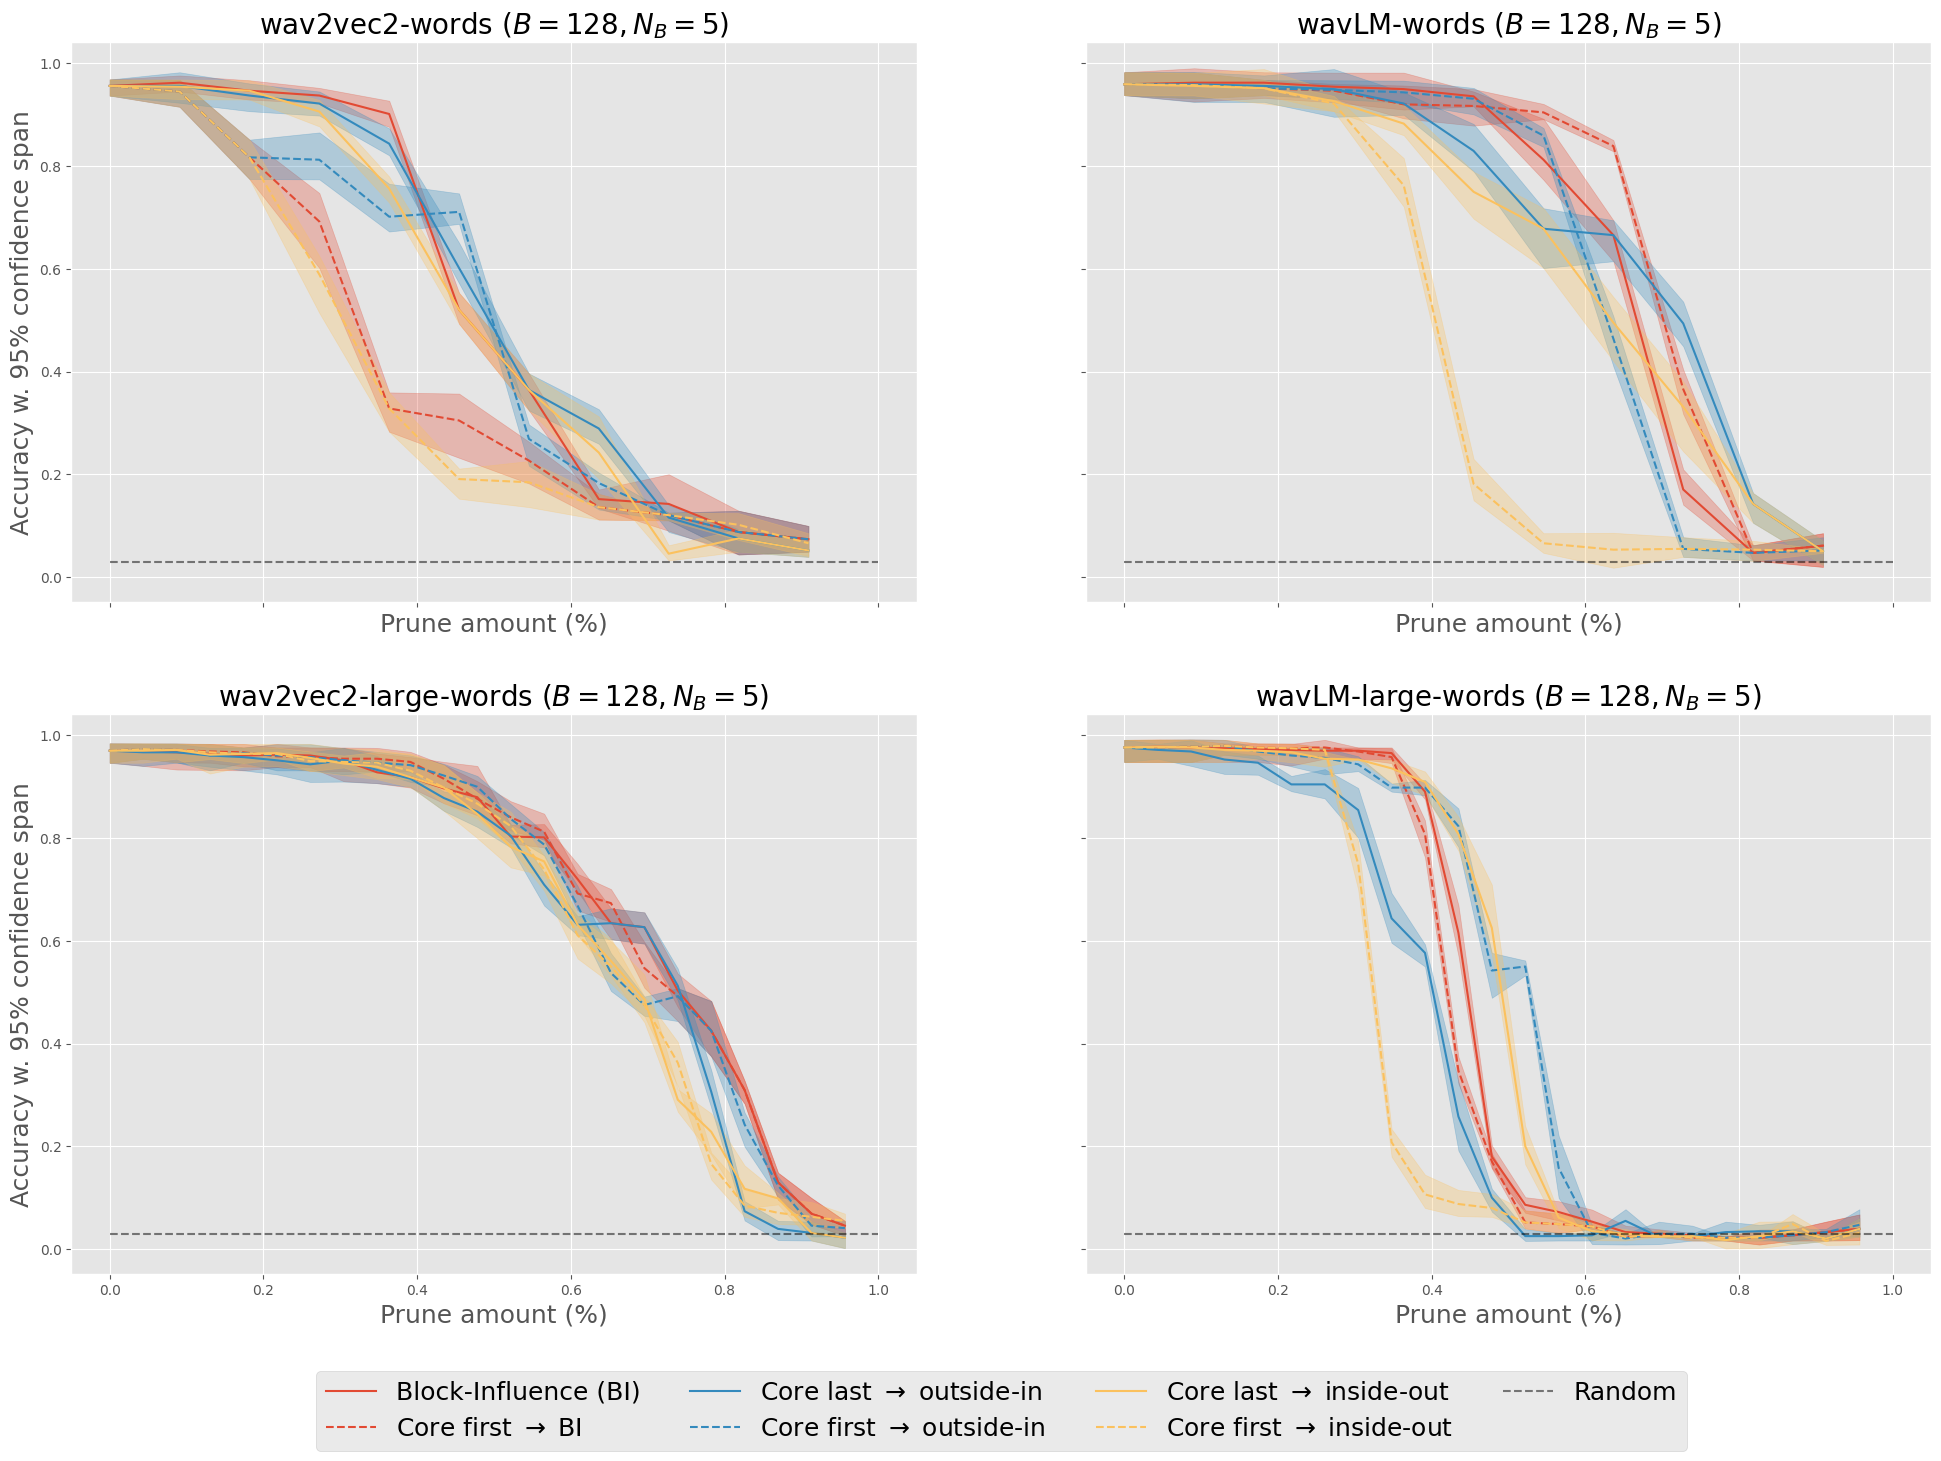

In [18]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/pruning")

num_classes = 35
_conf = 95
_alpha = round((1 - _conf / 100), 2)

fig, axs = plt.subplots(2, 2, figsize=(8*(2 + 1), 16), sharey=True, sharex='col')

for _row, size in enumerate(['', '-large']):
    for a, a_name in enumerate(['outside-in-core-last', 'outside-in-core-first', 'inside-out-core-last', 'inside-out-core-first']):
        ls = '-' if 'core-last' in a_name else '--'
        color = 'C4' if 'inside-out' in a_name else 'C1'
        name = f'Core {a_name.split("-")[-1]} $\\rightarrow$ {"-".join(a_name.split("-")[:2])}'

        if a_name == 'outside-in-core-last': #and size == '':
            all_results = {
                f'wav2vec2{size}-words': torch.load(EXP_PATH / a_name / f"audio/wav2vec2{size}-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['block-influence', 'knn-block-influence']_results.pth"),
                f'wavLM{size}-words': torch.load(EXP_PATH / a_name / f"audio/wavLM{size}-words/within=False_['pruning-performance']_start-iter=0_pruned-by=['block-influence', 'knn-block-influence']_results.pth"),
            }

        else:
            all_results = {
                f'wav2vec2{size}-words': torch.load(EXP_PATH / a_name / f"audio/wav2vec2{size}-words/within=False_['pruning-performance']_start-iter=0_pruned-by=[]_results.pth"),
                f'wavLM{size}-words': torch.load(EXP_PATH / a_name / f"audio/wavLM{size}-words/within=False_['pruning-performance']_start-iter=0_pruned-by=[]_results.pth"),
            }


        for i, (exp_name, results) in enumerate(all_results.items()):
            if a == 0:
                n_batches = results['accuracy']['block-influence'][0].__len__()
                batch_size = results['all-block-influences'][0].shape[0]
                num_layers = results['all-block-influences'][0].shape[1] + 1

                for strat_ in ['block-influence', 'core-first-block-influence']:
                    mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][strat_].items()}
                    lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][strat_].items()}
                    upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][strat_].items()}
    
                    xaxis = np.arange(len(mean_accs.keys())) / len(mean_accs.keys())
                    axs[_row, i].fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3, color='C0')
                    axs[_row, i].plot(xaxis, list(mean_accs.values()), label='Core first $\\rightarrow$ BI' if 'core' in strat_ else '$k$NN' if 'knn' in strat_ else 'Block-Influence (BI)', linestyle='--' if 'core' in strat_ else '-', color='C0' if 'knn' not in strat_ else 'C3')
                    
            pruning_strategy = 'custom'
            mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
            lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
            upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
            
            xaxis = np.arange(len(mean_accs.keys())) / len(mean_accs.keys())
            axs[_row, i].fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3, color=color)
            axs[_row, i].plot(xaxis, list(mean_accs.values()), label=name if pruning_strategy == 'custom' else pruning_strategy, linestyle=ls, color=color)
            axs[_row, i].set_xlabel('Prune amount (%)', fontsize=18)
            axs[_row, i].set_title(f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)', fontsize=20)

    axs[_row, 0].set_ylabel(f'Accuracy w. {_conf}% confidence span', fontsize=18)

for i in range(2):
    for j in range(2):
        axs[i, j].hlines(1/num_classes, xmin=0, xmax=1, color='black', linestyle='--', alpha=0.5, label='Random')

axs[0, 0].legend(fontsize=18, bbox_to_anchor=(1.1, -1.35), loc='upper center', ncols=4)
plt.show()

### Procrustes

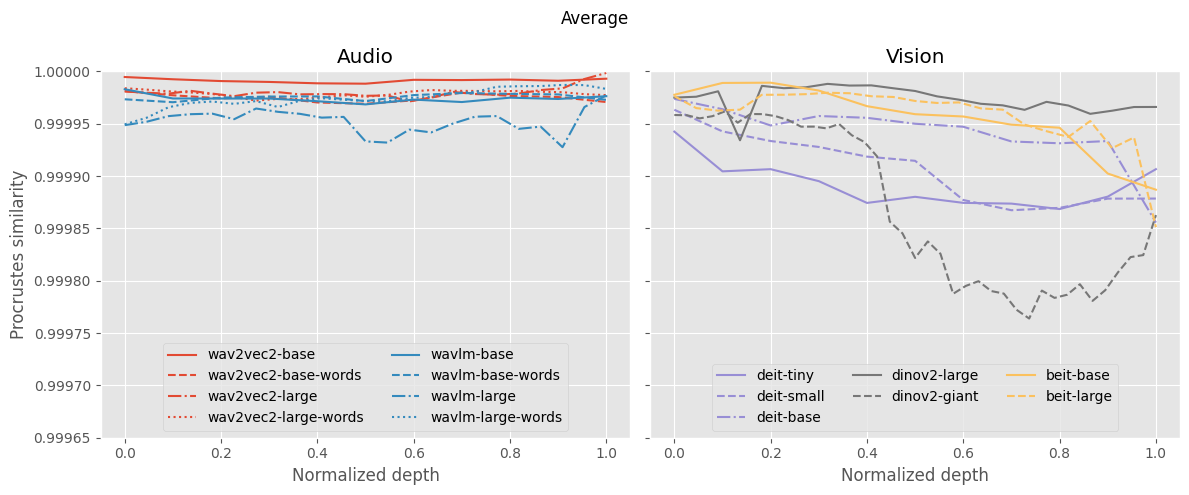

In [14]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments")

experiments = {
    'wav2vec2-base': EXP_PATH / "audio/wav2vec2-base/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wav2vec2-base-words': EXP_PATH / "audio/wav2vec2-words/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wav2vec2-large': EXP_PATH / "audio/wav2vec2-large/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wav2vec2-large-words': EXP_PATH / "audio/wav2vec2-large-words/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wavlm-base': EXP_PATH / "audio/wavlm-base/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wavLM-base-words': EXP_PATH / "audio/wavLM-words/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wavlm-large': EXP_PATH / "audio/wavlm-large/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'wavlm-large-words': EXP_PATH / "audio/wavlm-large-words/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    
    'deit-tiny': EXP_PATH / "vision/deit-tiny/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'deit-small': EXP_PATH / "vision/deit-small/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'deit-base': EXP_PATH / "vision/deit-base/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'dinov2-large': EXP_PATH / "vision/dinov2-large-imagenet1k-1-layer/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'dinov2-giant': EXP_PATH / "vision/dinov2-giant-imagenet1k-1-layer/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'beit-base': EXP_PATH / "vision/beit-base/within=True_['procrustes-similarity']_start-iter=0_results.pth",
    'beit-large': EXP_PATH / "vision/beit-large/within=True_['procrustes-similarity']_start-iter=0_results.pth",

    # 'roberta-base': EXP_PATH / "text/roberta-base-go_emotions/within=True_['procrustes-similarity']_start-iter=0_results.pth",
}

previous_exp = ''
color_idx = -1
linestyle_idx = 0
linestyles = ['-', '--', '-.', ':']

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for exp_name, exp_path in experiments.items():
    exp_name = exp_name.lower()

    if exp_name.split("-")[0] in previous_exp:
        linestyle_idx += 1
    else:
        color_idx += 1
        linestyle_idx = 0

    if 'audio' in exp_path.as_posix():
        domain = 'audio'
        j = 0
    elif 'vision' in exp_path.as_posix():
        domain = 'vision'
        j = 1
    elif 'text' in exp_path.as_posix():
        domain = 'text'
        j = 2

    sims = torch.load(exp_path)
    sims = torch.tensor([sims['all-procrustes-similarities'][i]['between'] for i in range(50)])

    xaxis = torch.linspace(0, 1, len(sims.mean(dim=0)))
    # axs[j].plot(xaxis, sims.mean(dim=0), label=exp_name, color=f'C{color_idx}', linestyle=linestyles[linestyle_idx], marker='x')
    axs[j].plot(xaxis, sims.mean(dim=0), label=exp_name, color=f'C{color_idx}', linestyle=linestyles[linestyle_idx])
    # axs[j].fill_between(xaxis, sims.quantile(dim=0, q=0.05), sims.quantile(dim=0, q=0.95), alpha=0.2, color=f'C{color_idx}')
    axs[j].set_xlabel('Normalized depth')
    axs[j].set_title(domain.capitalize())
    previous_exp = exp_name

# axs[0].set_ylim(0.5, 1.1)
axs[0].legend(ncols=2, loc='lower center'); 
axs[1].legend(ncols=3, loc='lower center'); 
axs[1].set_ylim(0.99965, 1.)
# axs[2].legend()
axs[0].set_ylabel('Procrustes similarity')
fig.suptitle('Average')
plt.tight_layout()
plt.show()

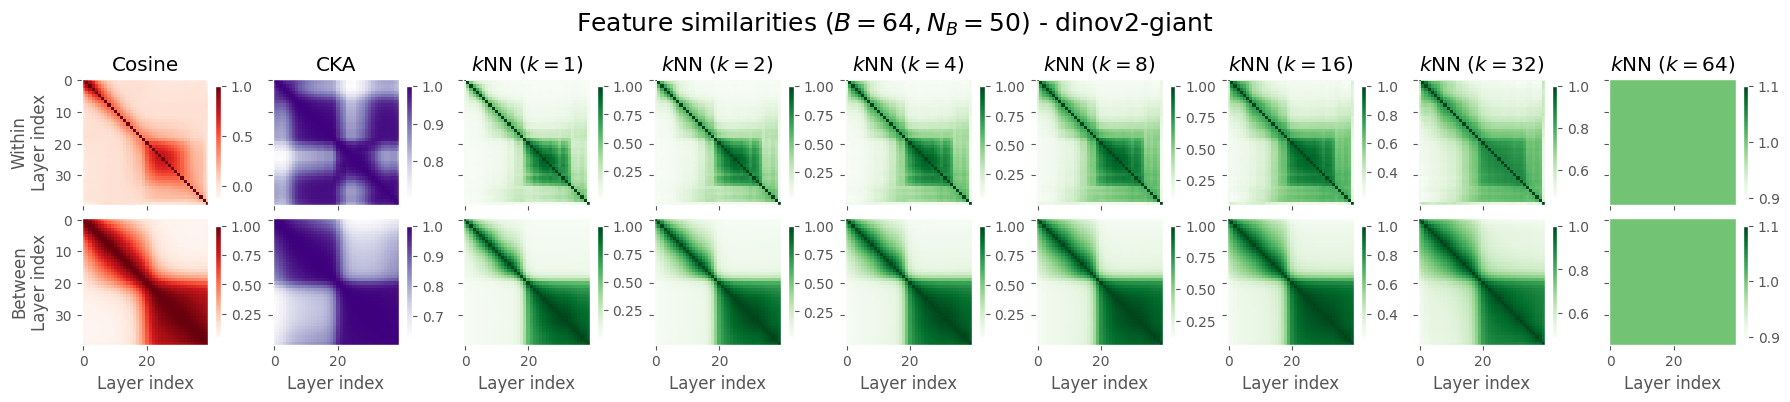

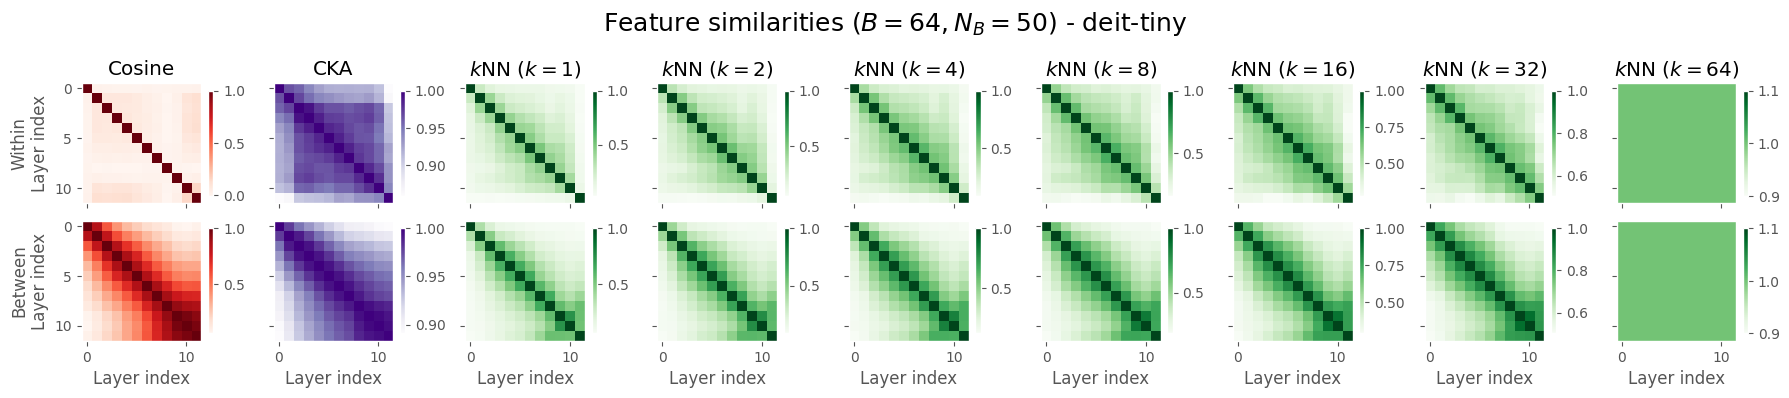

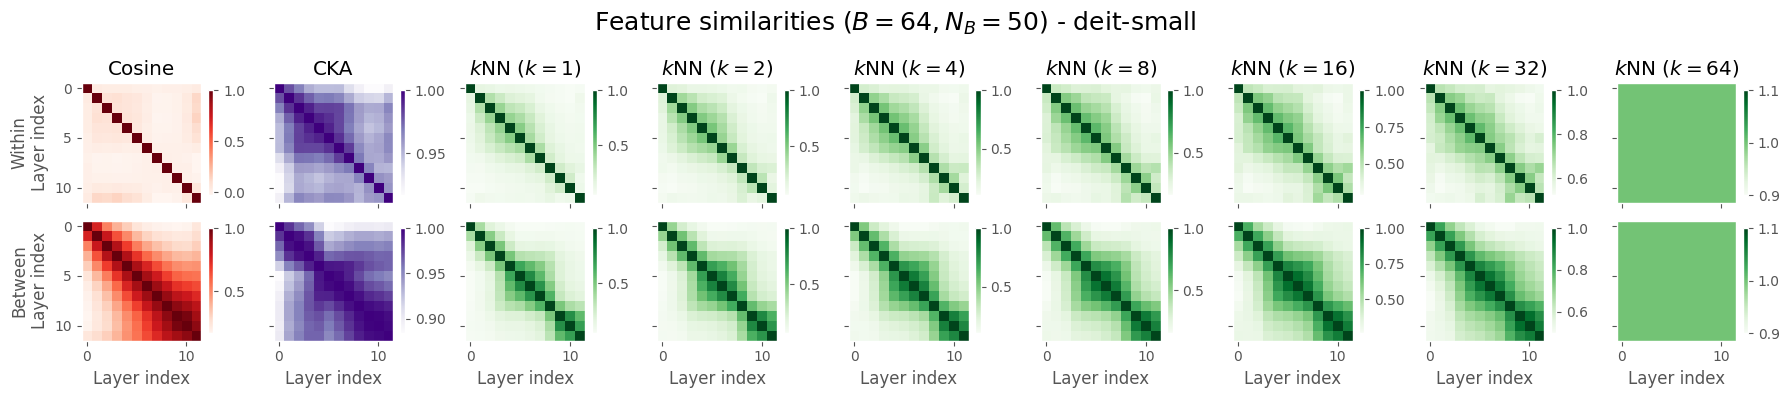

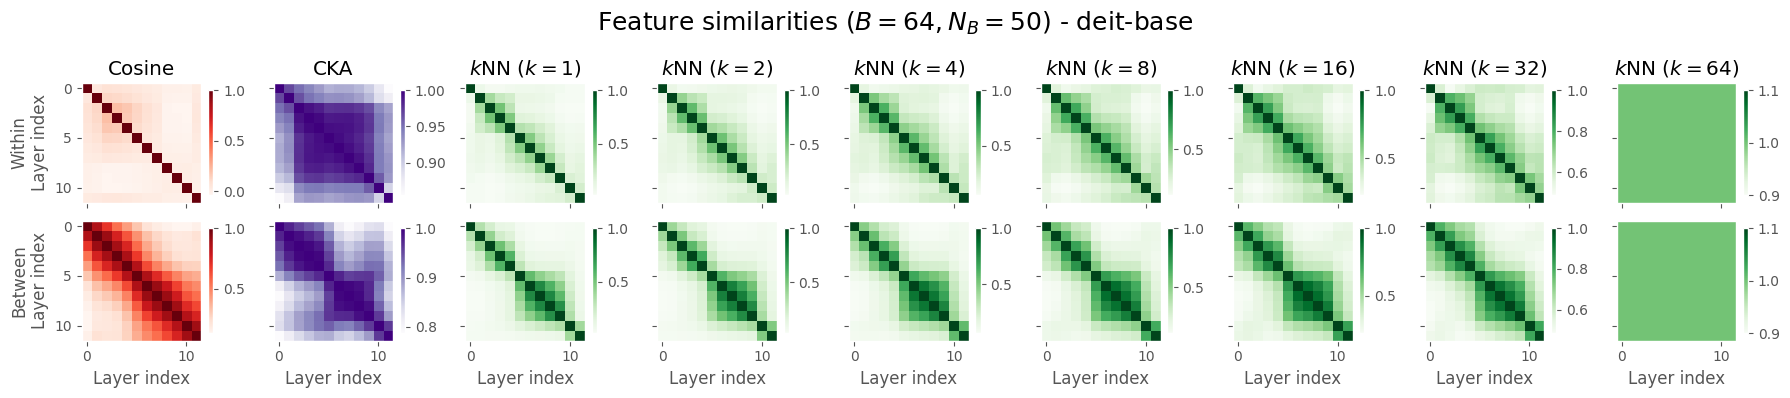

In [8]:
EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/similarities")

experiments = {
    'dinov2-giant': EXP_PATH / "vision/dinov2-giant-imagenet1k-1-layer/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'deit-tiny': EXP_PATH / "vision/deit-tiny/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'deit-small': EXP_PATH / "vision/deit-small/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
    'deit-base': EXP_PATH / "vision/deit-base/within=True_['cosine-similarity', 'mutual-knn', 'cka-similarity']_start-iter=0_results.pth",
}

for exp_name, exp_path in experiments.items():
    # Load results
    res = torch.load(exp_path)
    
    # Extract cosine similarities
    cos_within = torch.stack([elem['within'] for elem in res['all-cosine-similarities']])
    cos_between = torch.stack([elem['between'] for elem in res['all-cosine-similarities']])
    N_b = cos_within.shape[0]
    
    # Extract CKA similarities
    cka = torch.stack(res['all-cka-similarities'])
    cka_within = cka[:, ::2, ::2]
    cka_between = cka[:, 1::2, 1::2]

    # Extract mutual kNN similarities
    ks = res['all-mutual_knn-similarities']['within'][0].keys()
    mutual_knn_within = {k: torch.stack([res['all-mutual_knn-similarities']['within'][i][k] for i in range(N_b)]) for k in ks}
    mutual_knn_between = {k: torch.stack([res['all-mutual_knn-similarities']['between'][i][k] for i in range(N_b)]) for k in ks}

    fig, axs = plt.subplots(2, len(ks) + 2, figsize=(2*(len(ks) + 2), 4), sharex=True, sharey=True)
    
    # Plot cosine and CKA similarities
    plot_similarity_matrix(axs[0, 0], cos_within.mean(dim=0), 'cosine')
    plot_similarity_matrix(axs[1, 0], cos_between.mean(dim=0), 'cosine')
    axs[0, 0].set_title("Cosine")
    plot_similarity_matrix(axs[0, 1], cka_within.mean(dim=0), 'cka')
    plot_similarity_matrix(axs[1, 1], cka_between.mean(dim=0), 'cka')
    axs[0, 1].set_title('CKA')

    # Plot kNN similarities
    plot_knn_similarities(ks, mutual_knn_within, mutual_knn_between, exp_name, offset=2)

    axs[0, 0].set_ylabel("Within\nLayer index")
    axs[1, 0].set_ylabel("Between\nLayer index")
    axs[1, 0].set_xlabel('Layer index'); axs[1, 1].set_xlabel('Layer index')

    fig.suptitle(f"Feature similarities ($B={max(ks)}, N_B = {N_b}$) - {exp_name}", fontsize=18)
    plt.tight_layout()
    plt.show()

```
dinov2-giant (last - outside-in): 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 39 38 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 17 18 19 
dinov2-giant (first - outside-in): 19 18 17 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 39 38 37 36 35 34 33 32 31 30 29 28 27 26 25 24 23 22 21 20 

dinov2-giant (last - inside-out):  16 15 14 13 12 11 10 9 8 7 6 5 4 3 2 1 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 17 18 19 
dinov2-giant (first - inside-out): 19 18 17 16 15 14 13 12 11 10 9 8 7 6 5 4 3 2 1 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39
```

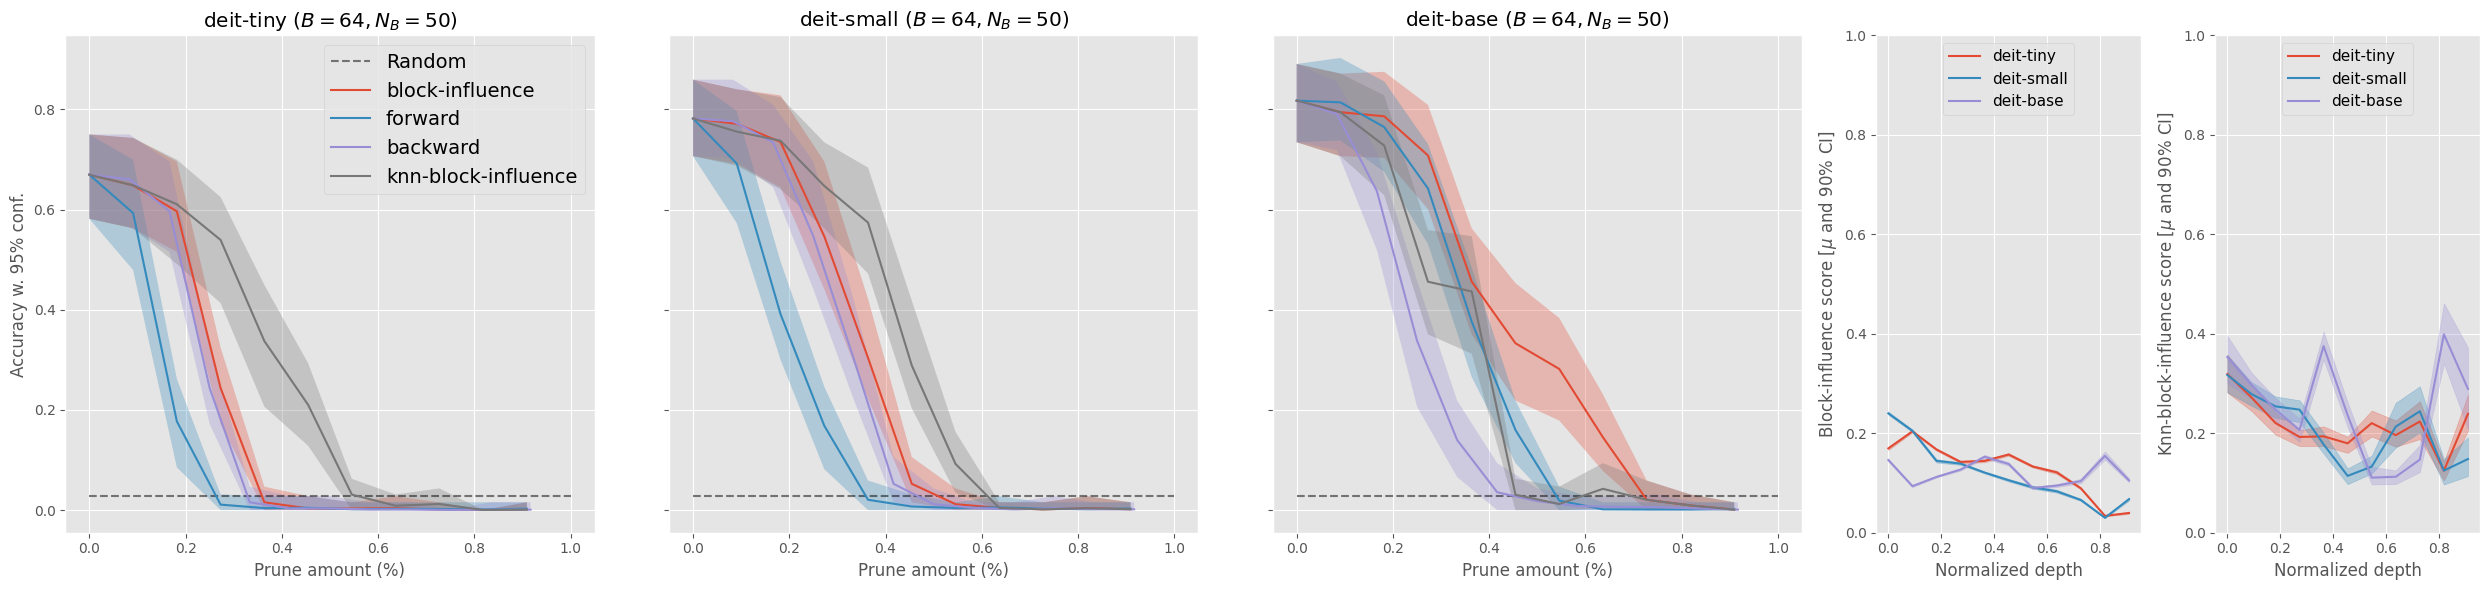

In [7]:
num_classes = 35
_conf = 95
_alpha = round((1 - _conf / 100), 2)

EXP_PATH = Path("C:/Users/alber/Desktop/DTU/4_HCAI/convexity/transformer_redundancy/experiments/pruning/adaptive")

fig, axs = plt.subplots(1, 3+2, figsize=(5*(3+2), 6), sharey=True, gridspec_kw={'width_ratios': [1, 1, 1, 0.5, 0.5]}, sharex='col', squeeze=False)

_row = 0
all_results = {
    f'deit-tiny': torch.load(EXP_PATH / f"vision/deit-tiny/bs64_50iter_results.pth"),
    f'deit-small': torch.load(EXP_PATH / f"vision/deit-small/bs64_50iter_results.pth"),
    f'deit-base': torch.load(EXP_PATH / f"vision/deit-base/bs64_50iter_results.pth"),
}
for i, (exp_name, results) in enumerate(all_results.items()):
    n_batches = results['accuracy']['forward'][0].__len__()
    batch_size = results['all-block-influences'][0].shape[0]
    num_layers = results['all-block-influences'][0].shape[1] + 1

    axs[_row, i].hlines(1/num_classes, xmin=0, xmax=1, color='black', linestyle='--', alpha=0.5, label='Random')

    for pruning_strategy in ['block-influence', 'forward', 'backward', 'knn-block-influence']:
        mean_accs = {k: torch.tensor(v).mean().item() for k, v in results['accuracy'][pruning_strategy].items()}
        lower_accs = {k: torch.tensor(v).quantile(_alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}
        upper_accs = {k: torch.tensor(v).quantile(1 - _alpha / 2).item() for k, v in results['accuracy'][pruning_strategy].items()}

        xaxis = np.arange(len(mean_accs.keys())) / len(mean_accs.keys())
        axs[_row, i].fill_between(xaxis, list(lower_accs.values()), list(upper_accs.values()), alpha=0.3)
        axs[_row, i].plot(xaxis, list(mean_accs.values()), label=pruning_strategy)

    axs[_row, i].set(xlabel='Prune amount (%)', title=f'{exp_name} ($B = {batch_size}, N_B = {n_batches}$)')
    # axs[_row, i].set_xticks(range(num_layers)[::num_layers // 10], range(num_layers)[::num_layers // 10])
axs[_row, 0].set(ylabel=f'Accuracy w. {_conf}% conf.')

axs[0, 0].legend(loc='upper right', fontsize=14)

# Plot block influence scores
experiments = {
    f'deit-tiny': EXP_PATH / f"vision/deit-tiny/bs64_50iter_results.pth",
    f'deit-small': EXP_PATH / f"vision/deit-small/bs64_50iter_results.pth",
    f'deit-base': EXP_PATH / f"vision/deit-base/bs64_50iter_results.pth",
}

for _ax_idx in [3, 4]:
    gs = axs[0, 2].get_gridspec()
    # remove the underlying Axes
    for ax in axs[0:, _ax_idx]:
        ax.remove()
    axbig = fig.add_subplot(gs[0:, _ax_idx])
    plot_heuristic(experiments, axbig, res_per_exp=1, relative_layer_idx=True, heuristic='block-influence' if _ax_idx == 3 else 'knn-block-influence')
    axbig.set_ylim(0., 1.)
    axbig.legend(loc='upper center', fontsize=11)

plt.tight_layout()
plt.show()